In [1]:
import numpy as np
import pandas as pd
from pandas.plotting import parallel_coordinates

import shap

from scipy.sparse import diags, csr_matrix, hstack, vstack

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.pipeline import Pipeline, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

/Users/anthony/anaconda3/envs/cb_seminar/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Dataset Overview: CiteULike
For this seminar, we will focus on the CiteULike dataset, a widely used benchmark in the domain of recommender systems. CiteULike is a web service that allows users to bookmark and tag scientific articles, providing a rich source of interaction data between users and scholarly publications.

### Key Characteristics:
- Users : The dataset includes interactions from 5,551 unique users , representing a diverse range of research interests.
- Items (Articles) : There are 16,980 scientific articles available in the dataset. Each article is described by its title and abstract , which are concatenated together to form a comprehensive textual representation.
- Textual Representation : To simplify the modeling process, we have already preprocessed the textual descriptions of the articles. Specifically, we extracted the 8,000 most important word tokens based on their frequency and relevance. These - tokens serve as the feature space for our model, enabling us to capture meaningful semantic information about the articles.

This dataset provides an ideal foundation for exploring content-based recommendation techniques, as it combines user preferences with detailed item descriptions in a structured format.

### Predicting Article Interactions Using Textual Descriptions
Our primary goal is to develop a content-based model that leverages the textual descriptions of articles to predict the likelihood or intensity of interactions with articles. In this context, "interactions" could refer to actions such as bookmarking, tagging, or reading an article. The purpose of this seminar is to introduce you to simple content-based models and analyze how content-based features impact the model's ability to make accurate predictions. We will consider more complex and personalized models later in this course.

Each row in the dataframe corresponds to a specific user, and the columns represent the articles they have interacted with. The interactions are encoded as strings containing article identifiers, where each string lists the articles associated with a particular user.

In [2]:
history_raw = pd.read_csv('./citeulike-a/users.dat', engine='python', names=['itemid'])
history_raw.index.name = 'userid'
history_raw['itemid'] = history_raw['itemid'].str.split(' ').apply(lambda x: [int(i) for i in x])
history_raw

,itemid
userid,
0,"[70, 495, 1631, 2317, 2526, 2846, 2931, 3171, ..."
1,"[38, 493, 942, 1519, 1843, 1844, 1896, 2819, 3..."
2,"[20, 517, 791, 800, 1329, 1767, 1984, 2126, 30..."
3,"[12, 706, 709, 721, 755, 756, 776, 892, 895, 2..."
4,"[12, 761, 2678, 4034, 4035, 5439, 5494, 5758, ..."
...,...
5546,"[14, 132, 2588, 3120, 3147, 3351, 3575, 4499, ..."
5547,"[15, 679, 1234, 7135, 9026, 9978, 10681, 11087..."
5548,"[11, 11571, 11605, 15237, 15253, 15437, 15438,..."


In [3]:
items_raw = pd.read_csv('./citeulike-a/raw-data.csv', encoding='latin1')
items_raw.loc[:, 'doc.id'] = np.arange(len(items_raw))
items_raw

,doc.id,title,citeulike.id,raw.title,raw.abstract
0,0,the metabolic world of escherichia coli is not...,42.0,The metabolic world of Escherichia coli is not...,To elucidate the organizational and evolutiona...
1,1,reverse engineering of biological complexity,43.0,Reverse Engineering of Biological Complexity,Advanced technologies and biology have extreme...
2,2,exploring complex networks,44.0,Exploring complex networks,"The study of networks pervades all of science,..."
3,3,comparative assessment of largescale data sets...,46.0,Comparative assessment of large-scale data set...,Comprehensive protein protein interaction maps...
4,4,navigation in a small world,47.0,Navigation in a small world,The small-world phenomenon â the principle t...
...,...,...,...,...,...
16975,16975,life is physics evolution as a collective phen...,8273254.0,Life is physics: evolution as a collective phe...,Evolution is the fundamental physical process ...
16976,16976,limitations of nextgeneration genome sequence ...,8290615.0,Limitations of next-generation genome sequence...,High-throughput sequencing technologies promis...
16977,16977,accurate inference of transcription factor bin...,8305197.0,Accurate inference of transcription factor bin...,Accurate functional annotation of regulatory e...
16978,16978,software that goes with the flow in systems bi...,8331304.0,Software that goes with the flow in systems bi...,ABSTRACT: A recent article in BMC Bioinformati...


The preprocessed titles and abstracts, described by 8000 features: number of features in article, followed by (feature_id:number of features).

In [4]:
preprocessed_items_raw = pd.read_csv('./citeulike-a/mult.dat', engine='python', names=['features'])
preprocessed_items_raw.index.name = 'itemid'
preprocessed_items_raw

,features
itemid,
0,63 1:2 1666:1 132:1 901:1 1537:2 8:1 9:1 912:1...
1,59 1792:1 771:1 1859:1 518:1 2943:1 649:1 138:...
2,47 129:1 6:1 647:1 8:3 9:2 266:1 3467:1 2958:1...
3,36 128:1 385:1 2:1 390:2 136:1 9:1 10:1 779:1 ...
4,40 0:1 1410:1 8:1 9:1 394:3 130:1 18:1 275:1 6...
...,...
16975,76 1536:1 5285:1 1539:1 278:1 518:1 5889:1 264...
16976,68 2688:1 1:1 43:1 1814:1 1158:1 1159:1 648:1 ...
16977,69 0:1 2177:1 3:3 772:1 133:1 265:2 12:1 141:1...


Let's prepare the interactions and features data in csr format.

In [5]:
history_length = [len(s) for _, s in history_raw['itemid'].items()]

user_idx = np.repeat(np.arange(len(history_raw)), history_length)
item_idx = np.concatenate(history_raw['itemid'].values)

interactions_matrix = csr_matrix(
    (np.ones_like(item_idx), (user_idx, item_idx)),
    shape=(len(history_raw), len(items_raw))
)

In [6]:
interactions_matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 210504 stored elements and shape (5551, 16980)>

In [7]:
splitted_features = preprocessed_items_raw['features'].str.split(' ')

features_length = splitted_features.apply(lambda x: int(x[0])).values

feature_idx    = np.concatenate(splitted_features.apply(lambda x: [int(el.split(':')[0]) for el in x[1:]]).values)
multiplicities = np.concatenate(splitted_features.apply(lambda x: [int(el.split(':')[1]) for el in x[1:]]).values)
item_idx       = np.repeat(np.arange(len(items_raw)), features_length)

feature_matrix = csr_matrix(
    (multiplicities, (item_idx, feature_idx)),
    shape=(len(preprocessed_items_raw), 8000)
)

In [8]:
feature_matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1130920 stored elements and shape (16980, 8000)>

In [9]:
interactions_matrix.astype(bool).sum(axis=0)

matrix([[19, 26, 85, ...,  7,  4, 11]], shape=(1, 16980))

The matplotlib.pyplot.spy function allows to look at the sparsity pattern of a matrix.

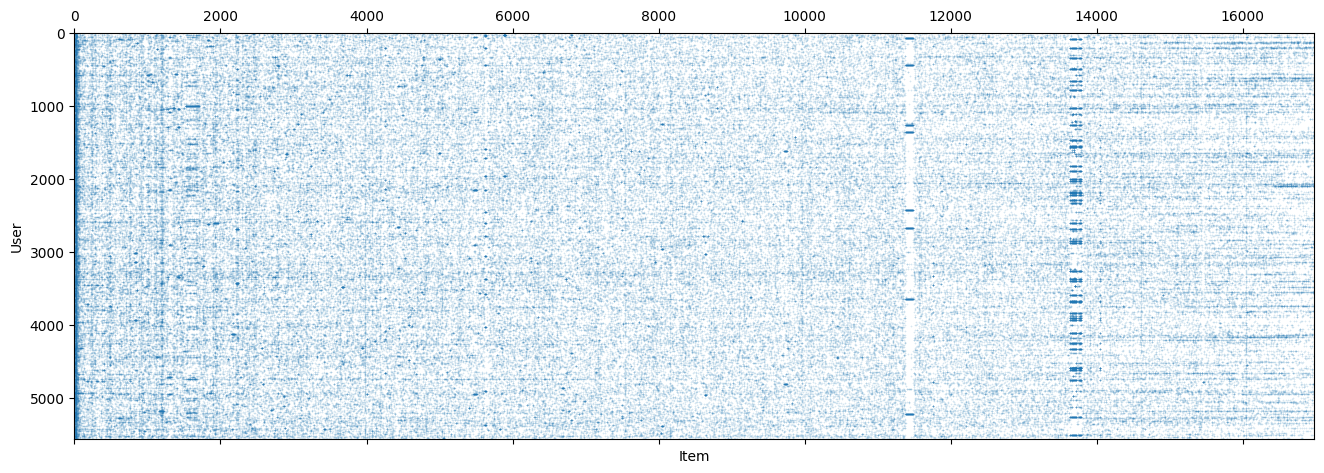

In [10]:
plt.figure(figsize=(16, 9))
plt.spy(interactions_matrix, markersize=0.05)
# plt.spy(interactions_matrix, markersize=0.01)
plt.ylabel('User')
plt.xlabel('Item')
plt.show()

In [11]:
(interactions_matrix > 0).sum() / (interactions_matrix.shape[0] * interactions_matrix.shape[1])

np.float64(0.0022333224905199647)

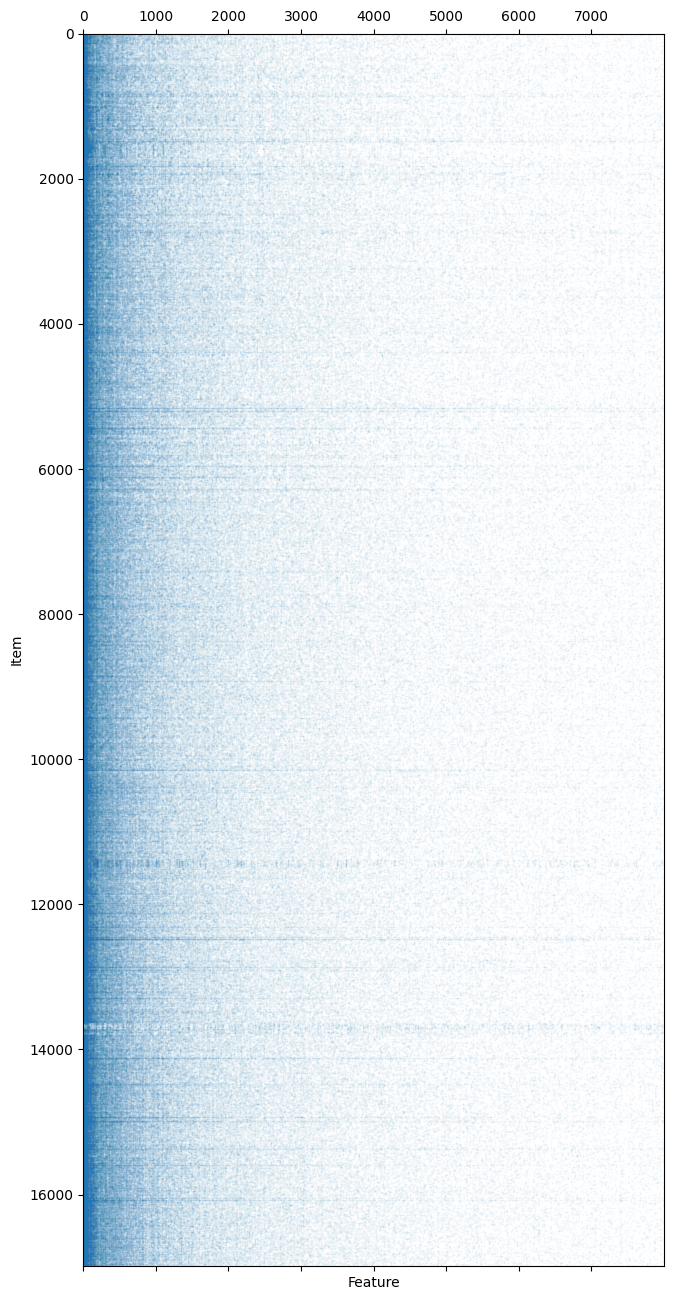

In [12]:
plt.figure(figsize=(9, 16))
plt.spy(feature_matrix, markersize=0.01)
plt.xlabel('Feature')
plt.ylabel('Item')
plt.show()

In [13]:
(feature_matrix > 0).sum() / (feature_matrix.shape[0] * feature_matrix.shape[1])

np.float64(0.008325382803297997)

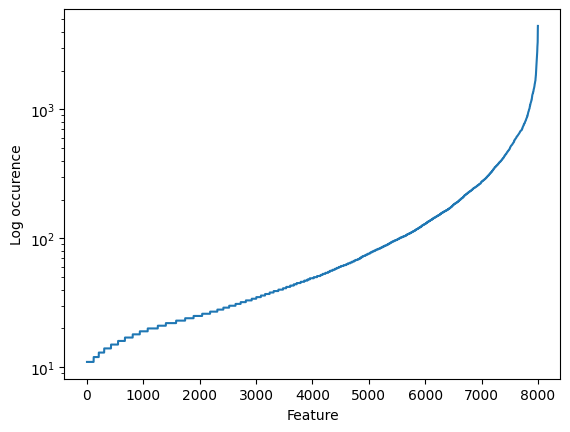

In [14]:
plt.semilogy(np.sort(feature_matrix.astype(bool).astype(int).sum(axis=0).A.squeeze()))
plt.xlabel('Feature')
plt.ylabel('Log occurence')
plt.show()

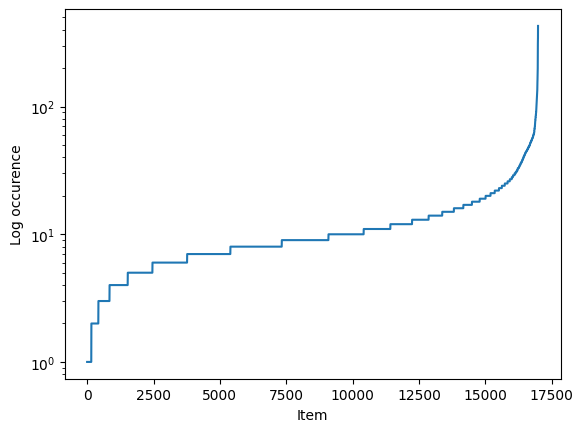

In [15]:
plt.semilogy(np.sort(interactions_matrix.sum(axis=0).A.squeeze()))
plt.xlabel('Item')
plt.ylabel('Log occurence')
plt.show()

In [16]:
vocab = pd.read_csv('./citeulike-a/vocabulary.dat', engine='python', names=['name'])
vocab

,name
0,information
1,analysis
2,new
3,gene
4,model
...,...
7995,psi
7996,quarterly
7997,rewardrelated
7998,simplex


Least occuring features

In [17]:
features_sorted_idx = np.argsort(feature_matrix.sum(axis=0).A.squeeze())

vocab.iloc[features_sorted_idx[:10]]

,name
7999,threeway
7998,simplex
7985,banks
7986,colocalized
7987,golden
7989,interferon
7990,metropolitan
7988,intercellular
7992,napster
7993,potts


Most occuring features

In [18]:
vocab.iloc[features_sorted_idx[-10:][::-1]]

,name
0,information
2,new
1,analysis
3,gene
4,model
6,systems
5,genes
7,results
10,methods
8,networks


Let's predict the popularity of a newly introduced article - how many users are going to interact with it. We can get the number of interactions by summing the interactions matrix across user dimension.

In [19]:
y = interactions_matrix.sum(axis=0).A.squeeze()
X = items_raw.copy()

We will split the data randomly, leaving 10\% of items for testing.

In [20]:
X_train_idx, X_test_idx, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=2025)

X_train = feature_matrix[X_train_idx.index]
X_test = feature_matrix[X_test_idx.index]

Make sure there are no items without any features.

In [21]:
print(f"train items w/o features: {(X_train.sum(axis=1) == 0).sum()}")
print(f"test items w/o features: {(X_test.sum(axis=1) == 0).sum()}")

train items w/o features: 0
test items w/o features: 0


Let's also look at the feature coverage

In [22]:
print(f"{(X_train.sum(axis=0) == 0).sum()} features are not presented in train")
print(f"{(X_test.sum(axis=0) == 0).sum()} features are not presented in test")

0 features are not presented in train
392 features are not presented in test


In [23]:
def evaluate(model, X, y):
    '''
    Computes RMSE and MAE scores
    '''
    y_pred = model.predict(X)
    results = pd.DataFrame.from_dict(
        {
            'index':[model.__class__.__name__],
            'columns': ['RMSE', 'MAE'],
            'data': [[np.sqrt(np.mean((y - y_pred) ** 2)), np.mean(np.abs(y - y_pred))]],
            'index_names':[None],
            'column_names':[None]
            },
        orient='tight'
    )
    return results

We will consider the Linear Regression model with its modifications. The main assumption is that the number of interactions linearly depends on the features of item:

$$
\bold{y}=\bold{X}\bold{w} +\bold{\epsilon}
$$
For a single data point k, the prediction is given by:
$$
y_k=\bold{x}_k^\top\bold{w} +\epsilon_k
$$

The optimization task is:

$$
\|\bold{y}-\bold{X}\bold{w}\|_2^2\rightarrow \min
$$

We can also add different regularizations - $l_1$ and $l_2$ norm of model's weights $\bold{w}$ with coefficients, resulting in Lasso($l_1$), Ridge($l_2$) and ElasticNet($l_1$+$l_2$) models.

In [24]:
model_zoo = [LinearRegression(), Ridge(), Lasso(), ElasticNet()]

results_no_preproc = pd.DataFrame()
for model in model_zoo:
    model.fit(X_train, y_train)
    results_no_preproc = pd.concat([results_no_preproc, evaluate(model, X_test, y_test)], axis=0)

In [25]:
results_no_preproc.round(2)

,RMSE,MAE
LinearRegression,21.13,14.33
Ridge,19.62,13.25
Lasso,10.56,6.36
ElasticNet,10.51,6.31


In [26]:
for model in model_zoo:
    print(model.__class__.__name__)
    print(f'w0={model.intercept_:.2f}, ||w||={np.linalg.norm(model.coef_):.2f}')

LinearRegression
w0=11.99, ||w||=246.66
Ridge
w0=11.96, ||w||=214.27
Lasso
w0=12.20, ||w||=0.84
ElasticNet
w0=11.96, ||w||=1.00


In [27]:
vocab.iloc[np.abs(model_zoo[0].coef_).argsort()[::-1][:10]]

,name
7059,listserv
7038,americas
4860,generalizations
7624,cellcell
6776,prime
5374,military
7022,divisions
7492,extremes
6159,hackers
7099,russian


In [28]:
feature_matrix.toarray().max(axis=0)

array([71, 22, 20, ...,  3,  3,  6], shape=(8000,))

# Interpreting Models with SHAP

To enhance the interpretability of our Linear Regression model and its regularized variants (Ridge, Lasso, Elastic Net), we will utilize **SHAP** (**SH**apley **A**dditive ex**P**lanations). SHAP is a game-theoretic approach for explaining the output of machine learning models, providing insights into how each feature contributes to individual predictions.

What Are SHAP Values?
SHAP values are based on the concept of Shapley values from cooperative game theory. They assign a value to each feature for a given prediction, representing the contribution of that feature to the final output. Key properties of SHAP values include:

Local Accuracy : The sum of the SHAP values for all features plus the base value equals the model's output for that instance.
Consistency : If a feature contributes more to the prediction when compared to another feature, its SHAP value will be higher.
Missingness : Features that are missing or irrelevant have no impact on the prediction.


For further guidance and inspiration, refer to the official SHAP documentation and several blogposts:
- https://shap.readthedocs.io/en/latest/index.html
- https://www.deepchecks.com/a-comprehensive-guide-into-shap-shapley-additive-explanations-values/
- https://medium.com/towards-data-science/a-novel-approach-to-feature-importance-shapley-additive-explanations-d18af30fc21b



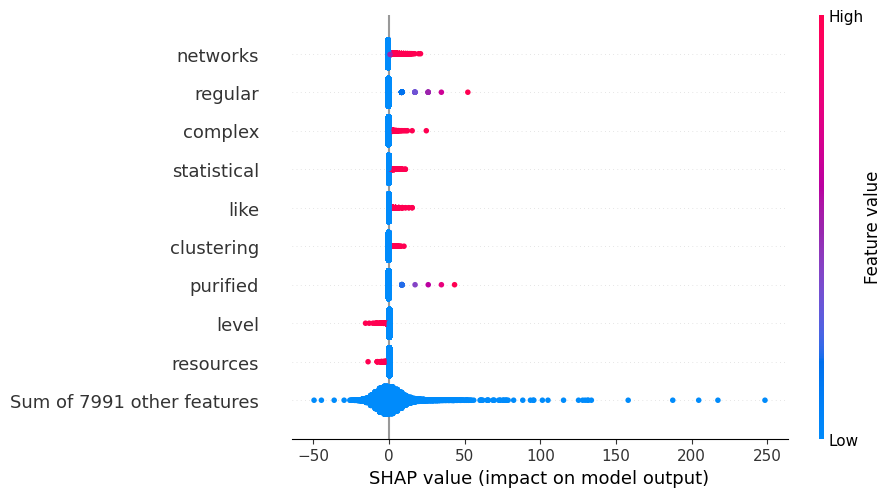

In [29]:
explainer = shap.explainers.Linear(model_zoo[0], X_train, feature_names=vocab['name'])
shap_values = explainer(X_train)

shap.plots.beeswarm(shap_values, max_display=10)

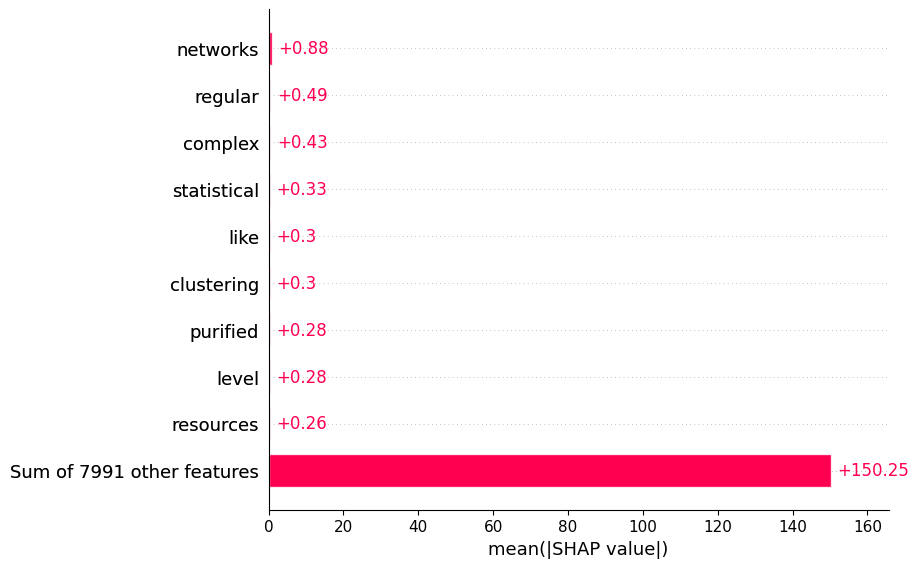

In [30]:
shap.plots.bar(shap_values, max_display=10)

In [31]:
index = 1000
X_train_idx.loc[index]

doc.id                                                       1000
title           selection of relevant features and examples in...
citeulike.id                                             109765.0
raw.title       Selection of Relevant Features and Examples in...
raw.abstract    In this survey, we review work in machine lear...
Name: 1000, dtype: object

In [32]:
X_train_idx.loc[index]['raw.abstract'].split('.') + X_train_idx.loc[index]['raw.title'].split('.')

['In this survey, we review work in machine learning on methods for handling data sets containing large amounts of irrelevant information',
 ' We focus on two key issues: the problem of selecting relevant features, and the problem of selecting relevant examples',
 ' We describe the advances that have been made on these topics in both empirical and theoretical work in machine learning, and we present a general framework that we use to compare different methods',
 ' We close with some challenges for future work in this area',
 '',
 'Selection of Relevant Features and Examples in Machine Learning']

In [33]:
vocab.iloc[X_train[np.where(X_train_idx['doc.id'] == index)[0][0], :].indices].values.squeeze()

array(['information', 'methods', 'different', 'two', 'learning', 'large',
       'present', 'work', 'problem', 'selection', 'framework', 'features',
       'describe', 'general', 'sets', 'review', 'key', 'examples',
       'future', 'issues', 'made', 'relevant', 'theoretical', 'empirical',
       'machine', 'focus', 'area', 'challenges', 'survey', 'topics',
       'compare', 'advances', 'containing', 'close', 'amounts',
       'selecting', 'handling', 'irrelevant'], dtype=object)

We can also investigate how each particular feature impacts the output. Let's take our article with index 1000 and plot the 'waterfall'. In lower left corner the value $E[f(X)]=12.689$ is the averaged output on training data. In upper right $f(x)=16.807$ is the output for this particular article. The feature 'machine' has a positive effects on model's output, while 'irrelevant', 'selecting' and 'close' have negative impact.

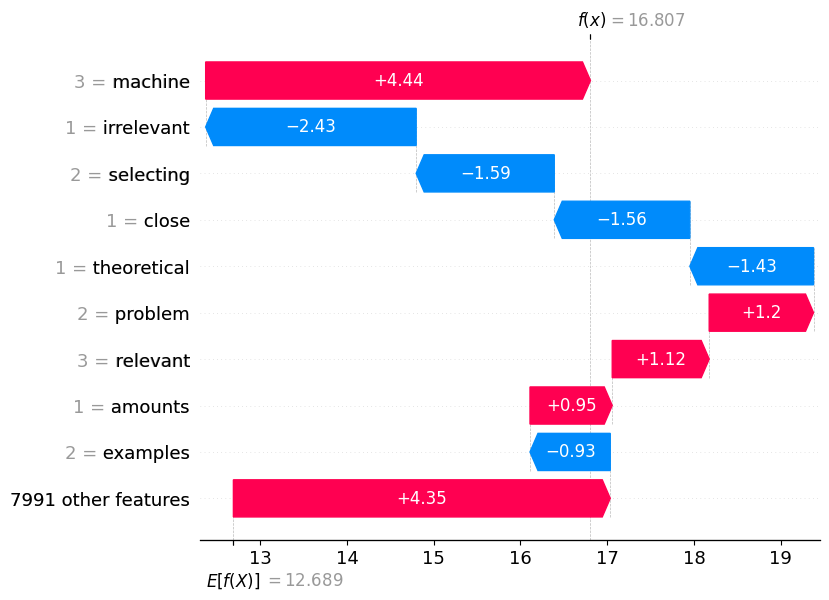

In [34]:
shap.plots.waterfall(shap_values[np.where(X_train_idx['doc.id'] == index)[0][0]], max_display=10)

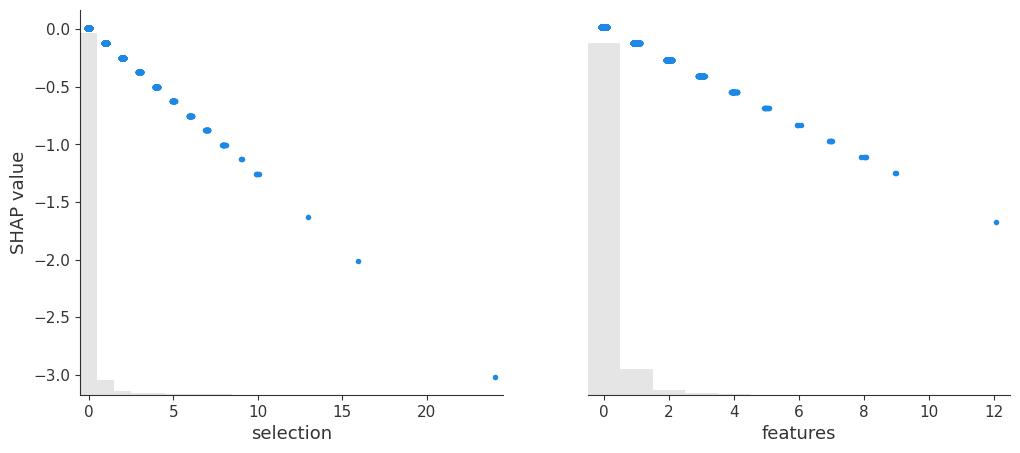

In [35]:
shap.plots.scatter(shap_values[:, ["selection", "features"]])

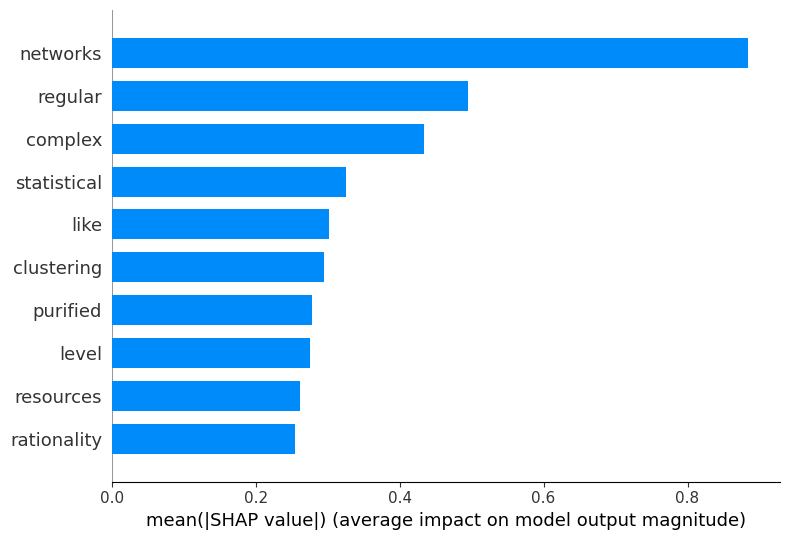

In [36]:
shap.summary_plot(shap_values, features=X_train, feature_names=vocab.values.squeeze(), plot_type='bar', max_display=10)

# Feature preprocessing

The next critical step in building our content-based recommendation system is feature preprocessing, where we transform the raw document-term matrix into a more meaningful representation that enhances the model's ability to capture relevant patterns. Two widely used techniques for this purpose are TF-IDF (Term Frequency-Inverse Document Frequency) and feature scaling . While these methods provide robust starting points, it's important to recognize that feature preprocessing is as much an art as it is a science—requiring creativity, domain knowledge, and iterative experimentation.

### TF-IDF
The document-term matrix represents each article as a vector of word frequencies. However, raw frequency counts can be misleading because common words (e.g., "the," "and") appear frequently across all documents but carry little discriminative power. To address this issue, TF-IDF adjusts term weights by considering both their frequency within a document and their rarity across the corpus.

The TF-IDF weight for a term t in document d is calculated as:

TF-IDF(t,d)=TF(t,d)×IDF(t)

$$
\text{TF}(t, d) = \frac{f_{t, d}}{\sum_{t'\in d}f_{t', d}}
$$
$$
\text{IDF}(t, D) = \log\left( \frac{N}{1 + |\{d\in D: t\in d\}|} \right) + 1
$$

In [37]:
class TFIDF_Transformer(TransformerMixin):
    '''
    Apply TF-IDF transformation to the document-term matrix
    '''

    def fit(self, X, y=None, **fit_params):
        self.corpus = X.copy()
        idf_scores = self.corpus.astype(bool).sum(axis=0).A.squeeze()
        self.idf = diags(np.log(self.corpus.shape[0] / (1.0 + idf_scores)) + 1.0)
        return self
    
    def transform(self, X, y=None, **fit_params):
        D = diags(1.0 / X.sum(axis=1).A.squeeze())
        tfidf = D @ X @ self.idf
        return tfidf

In [38]:
class DenseTransformer(TransformerMixin):
    """
    Convert sparse matrix to dense np array to apply standard scaler with mean.
    """

    def fit(self, X, y=None, **fit_params):
        return self

    def transform(self, X, y=None, **fit_params):
        return X.toarray()

### Feature Scaling
After applying TF-IDF, the resulting feature values may span several orders of magnitude, depending on the dataset. This can lead to numerical instability or bias in models that rely on distance metrics. To mitigate this issue, feature scaling standardizes the range of features, ensuring that no single feature dominates the others due to its scale.



In [39]:
word_vectorizer = Pipeline([
    ("tfidf", TFIDF_Transformer()), 
    ("dense", DenseTransformer()),
    ("scaler", StandardScaler())
])

word_vectorizer

,steps,"[('tfidf', ...), ('dense', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [40]:
model_zoo = [LinearRegression(), Ridge(), Lasso(), ElasticNet()]

feature_matrix_train = word_vectorizer.fit_transform(X_train)
results_tfidf = pd.DataFrame()
for model in model_zoo:
    model.fit(feature_matrix_train, y_train)
    results_tfidf = pd.concat([results_tfidf, evaluate(model, word_vectorizer.transform(X_test), y_test)], axis=0)

In [41]:
results_tfidf.round(2)

,RMSE,MAE
LinearRegression,18.71,13.76
Ridge,18.70,13.75
Lasso,10.49,6.30
ElasticNet,10.37,6.24


In [42]:
results_no_preproc.round(2)

,RMSE,MAE
LinearRegression,21.13,14.33
Ridge,19.62,13.25
Lasso,10.56,6.36
ElasticNet,10.51,6.31


In [43]:
model_zoo[0].coef_

array([ 0.08343934, -0.02783851, -0.09583095, ..., -0.08123005,
       -0.2299044 , -0.11625374], shape=(8000,))

In [44]:
vocab.iloc[np.abs(model_zoo[0].coef_).argsort()[::-1][:10]]

,name
4860,generalizations
2483,smallworld
3237,uncover
8,networks
574,tagging
668,shared
5936,vice
419,collaborative
3711,spectra
2794,regular


In [45]:
for model in model_zoo:
    print(model.__class__.__name__)
    print(f'w0={model.intercept_:.2f}, ||w||={np.linalg.norm(model.coef_):.2f}')

LinearRegression
w0=12.45, ||w||=15.99
Ridge
w0=12.45, ||w||=15.98
Lasso
w0=12.45, ||w||=1.28
ElasticNet
w0=12.45, ||w||=1.81


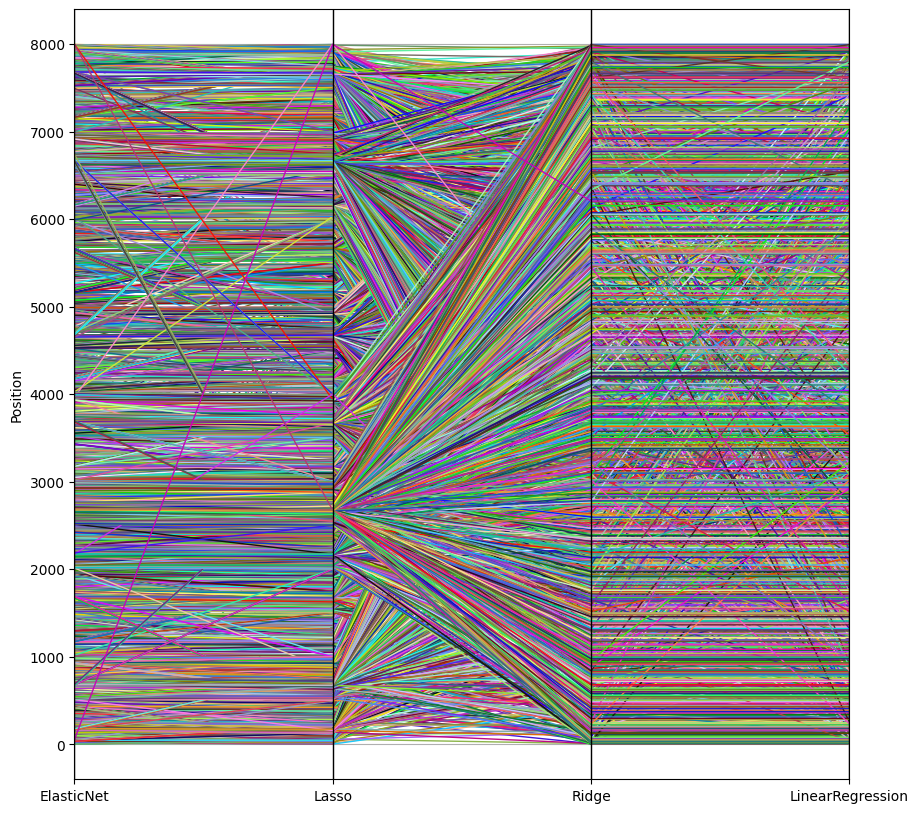

In [46]:
plt.figure(figsize=(10, 10))
weights_df = pd.DataFrame.from_dict({model.__class__.__name__: np.argsort(-model.coef_) for model in model_zoo})
weights_df['names'] = vocab.iloc[weights_df['Lasso']]


parallel_coordinates(
    weights_df,
    class_column='names',
    cols=['ElasticNet', 'Lasso', 'Ridge', 'LinearRegression'],
    linewidth=1
)

plt.ylabel('Position')
plt.gca().legend_.remove()

# Binary classification

In [47]:
X = feature_matrix.copy()
y_binary = (y >= 5).astype(int)

X_train, X_test, y_bin_train, y_bin_test = train_test_split(X, y_binary, test_size=0.1, random_state=2025)

In [48]:
word_vectorizer = Pipeline([
    ("tfidf", TFIDF_Transformer()),
])

feature_matrix_train = word_vectorizer.fit_transform(X_train)

model = LogisticRegression()
model.fit(feature_matrix_train, y_bin_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [49]:
np.round(
    accuracy_score(
        y_true=y_bin_test.astype(int),
        y_pred=model.predict(word_vectorizer.transform(X_test))
    ),
2).item()

/Users/anthony/anaconda3/envs/cb_seminar/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


0.92

In [50]:
np.round(
    accuracy_score(
        y_true=y_bin_test.astype(int),
        y_pred=(np.random.rand(len(y_bin_test)) >= 0.5).astype(int)
    ),
2).item()

0.51

We managed to beat the random baseline! 

# More personalization

In [51]:
np.min(history_length)

np.int64(11)

Lets take first 10 items as items than describes a user

In [52]:
X = []
y = []

for u, items in history_raw['itemid'].items():
    inference_items = items[:10]
    positive_items = items[10:]

    negative_items = np.random.choice(
        np.setdiff1d(
            np.arange(len(items_raw)),
            items
        ),
        size=len(positive_items),
        replace=False
    ).tolist()

    train_items = positive_items + negative_items

    user_feat = feature_matrix[inference_items].mean(axis=0).A.squeeze()

    X.append(
        csr_matrix(
            np.hstack([
                np.tile(user_feat, (len(train_items), 1)),
                feature_matrix[train_items].toarray()
            ])
        )
    )
    y.append(
        np.concatenate([
            np.ones(len(positive_items)),
            np.zeros(len(negative_items))
        ])
    )

X = vstack(X)
y = np.concatenate(y)

In [53]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 182405433 stored elements and shape (310054, 16000)>

We can check how much space of RAM we consume with X matrix

In [54]:
print(f"{((X != 0).sum() * 8) / 1024 / 1024:.2f} MB")

1391.64 MB


In [55]:
y[:150]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=True)

In [57]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [58]:
np.round(
    accuracy_score(
        y_true=y_test,
        y_pred=model.predict(X_test)
    ),
2).item()

0.57

In [59]:
np.round(
    accuracy_score(
        y_true=y_test,
        y_pred=(np.random.rand(len(y_test)) >= 0.5).astype(int)
    ),
2).item()

0.5